# Per-Eye (Per-Image) DR Detection — mBRSET

**Goal:** Evaluate frozen foundation-model embeddings for binary DR detection at the **individual eye** level,
rather than aggregating to patient level.

**Key differences vs patient-level notebook:**
- Each retinal image is one sample (no mean/max pooling across eyes)
- ~2× more samples (~2582 images vs 1291 patients)
- Cleaner labels: each image has its own `dr_grade` — no need for max() across eyes
- Simpler pipeline: embedding → PCA → scale → classify

**Data leakage prevention:** Both eyes of the same patient stay in the SAME split
(using the frozen patient split from checkpoint_run14).

**Pipeline per embedding:**
1. Load image-level embeddings + labels
2. Split images by patient_id (frozen split)
3. PCA(128) fit on train → transform both
4. StandardScaler fit on train → transform both
5. Train classifier (LogReg balanced, XGBoost)
6. Optimize threshold on train predictions (F1)
7. Evaluate on test set

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)
from sklearn.exceptions import ConvergenceWarning
from xgboost import XGBClassifier

from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

print("Imports complete.")

Imports complete.


## 1. Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════
# Per-Eye Evaluation — task_any_dr (Binary DR Detection)
# ═══════════════════════════════════════════════════════════════

PROJECT_ROOT = Path.cwd()
DATASET_NAME = "mbrset"
VIEW = "macula"
RANDOM_SEED = 42
PCA_N_COMPONENTS = 128
THRESHOLD_METHOD = "f1"
THRESHOLD_GRID_SIZE = 201

RESULTS_DIR = PROJECT_ROOT / "results" / "mbrset_per_eye_eval_any_dr"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {DATASET_NAME}")
print(f"View: {VIEW}")
print(f"PCA components: {PCA_N_COMPONENTS}")
print(f"Threshold: {THRESHOLD_METHOD} (grid={THRESHOLD_GRID_SIZE})")
print(f"Results dir: {RESULTS_DIR}")

Project root: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project
Dataset: mbrset
View: macula
PCA components: 128
Threshold: f1 (grid=201)
Results dir: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_per_eye_eval_any_dr


## 2. Load Frozen Patient Split

In [3]:
# ——— Load the SAME frozen patient split used in all other notebooks ———
_frozen_split_path = PROJECT_ROOT / "results" / "checkpoint_run14" / "patient_split.csv"
if not _frozen_split_path.exists():
    _frozen_split_path = PROJECT_ROOT / "results" / "mbrset_patient_eval" / "patient_split.csv"
if not _frozen_split_path.exists():
    raise FileNotFoundError(f"Frozen patient split not found at expected paths.")

_split_df = pd.read_csv(_frozen_split_path, dtype=str)
train_patient_ids = set(_split_df.loc[_split_df["split"] == "train", "patient_id"])
test_patient_ids  = set(_split_df.loc[_split_df["split"] == "test",  "patient_id"])

total_patients = len(train_patient_ids) + len(test_patient_ids)
print(f"Frozen patient split from: {_frozen_split_path}")
print(f"  Train patients: {len(train_patient_ids)} ({len(train_patient_ids)/total_patients:.0%})")
print(f"  Test patients:  {len(test_patient_ids)}  ({len(test_patient_ids)/total_patients:.0%})")

# Save copy for traceability
_split_df.to_csv(RESULTS_DIR / "patient_split.csv", index=False)

# List embedding files
embed_dir = PROJECT_ROOT / "data" / f"{DATASET_NAME}_embeddings"
labels_path = embed_dir / f"{DATASET_NAME}_labels" / f"labels_{DATASET_NAME}.csv"
embedding_files = list_embeddings_csvs(embed_dir)
print(f"\nFound {len(embedding_files)} embedding files:")
for i, f in enumerate(embedding_files):
    print(f"  {i}: {f.name}")

Frozen patient split from: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\checkpoint_run14\patient_split.csv
  Train patients: 1032 (80%)
  Test patients:  259  (20%)

Found 7 embedding files:
  0: Embeddings_convnextv2_base_mbrset.csv
  1: Embeddings_mbrset_dinov3_convnext_base.csv
  2: Embeddings_mbrset_dinov3_vitb16.csv
  3: Embeddings_mbrset_RETFound_dinov2_shanghai.csv
  4: Embeddings_mbrset_RETFound_mae_natureCFP.csv
  5: Embeddings_mbrset_RETFound_mae_shanghai.csv
  6: Embeddings_vit_base_mbrset.csv


## 3. Helper Functions

In [4]:
def find_optimal_threshold(y_true, y_proba, method="f1", grid_size=201):
    """Find optimal binary classification threshold on TRAIN data only."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if method == "f1":
        thresholds = np.linspace(0.01, 0.99, grid_size)
        best_t, best_f1 = 0.5, -1.0
        for t in thresholds:
            preds = (y_proba >= t).astype(int)
            f1 = float(f1_score(y_true, preds, zero_division=0))
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t
    elif method == "youden":
        fpr, tpr, thresholds = roc_curve(y_true, y_proba)
        j = tpr - fpr
        return float(thresholds[int(np.argmax(j))])
    raise ValueError(f"Unknown method: {method}")


def evaluate_binary(y_true, y_pred, y_proba):
    """Compute standard binary classification metrics."""
    return {
        "f1":        float(f1_score(y_true, y_pred, zero_division=0)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_true, y_pred, zero_division=0)),
        "auc":       float(roc_auc_score(y_true, y_proba)),
        "bal_acc":   float(balanced_accuracy_score(y_true, y_pred)),
    }


print("Helpers defined.")

Helpers defined.


## 4. Per-Eye Evaluation — All Embeddings × (LogReg, XGBoost)

For each of the 7 frozen embeddings:
1. Load image-level data (each row = one eye image)
2. Split into train/test by **patient_id** (data leakage prevention)
3. PCA(128) → StandardScaler (fit on train only)
4. Train LogisticRegression (balanced) and XGBClassifier
5. Optimize threshold on train predictions
6. Report test-set metrics

In [6]:
all_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    # Clean up embedding name for display
    display_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n{'='*70}")
    print(f"Embedding {emb_idx+1}/{len(embedding_files)}: {display_name}")
    print(f"{'='*70}")

    # ——— Load dataset (image-level) ———
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    df = ds.df.copy()
    df["patient_id"] = df["patient_id"].astype(str)   # match split dtype
    feat_cols = ds.feature_cols

    # Drop rows without task_any_dr label
    df = df.dropna(subset=["task_any_dr"]).reset_index(drop=True)
    df["task_any_dr"] = df["task_any_dr"].astype(int)

    # ——— Split by PATIENT (data leakage prevention) ———
    train_mask = df["patient_id"].isin(train_patient_ids)
    test_mask  = df["patient_id"].isin(test_patient_ids)

    df_train = df[train_mask].reset_index(drop=True)
    df_test  = df[test_mask].reset_index(drop=True)

    X_train = df_train[feat_cols].values.astype(np.float32)
    y_train = df_train["task_any_dr"].values
    X_test  = df_test[feat_cols].values.astype(np.float32)
    y_test  = df_test["task_any_dr"].values

    # Check for NaNs
    nan_train = np.isnan(X_train).sum()
    nan_test  = np.isnan(X_test).sum()
    if nan_train > 0 or nan_test > 0:
        print(f"  WARNING: NaN in features (train={nan_train}, test={nan_test}). Filling with 0.")
        X_train = np.nan_to_num(X_train, nan=0.0)
        X_test  = np.nan_to_num(X_test, nan=0.0)

    pos_train = y_train.sum()
    pos_test  = y_test.sum()
    print(f"  Images — train: {len(y_train)} (pos={pos_train}, {pos_train/len(y_train):.1%})")
    print(f"           test:  {len(y_test)}  (pos={pos_test}, {pos_test/len(y_test):.1%})")
    print(f"  Features: {X_train.shape[1]}-D")

    # ——— PCA (fit on train only) ———
    n_components = min(PCA_N_COMPONENTS, X_train.shape[1], X_train.shape[0])
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    var_explained = pca.explained_variance_ratio_.sum()
    print(f"  PCA: {X_train.shape[1]}→{n_components} ({var_explained:.1%} variance)")

    # ——— Scale (fit on train only) ———
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s  = scaler.transform(X_test_pca)

    # ——— Classifiers ———
    classifiers = {
        "LogReg_balanced": LogisticRegression(
            C=1.0, class_weight="balanced", max_iter=2000, random_state=RANDOM_SEED
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=max(1.0, (len(y_train) - pos_train) / max(pos_train, 1)),
            eval_metric="logloss",
            random_state=RANDOM_SEED,
            verbosity=0,
        ),
    }

    for clf_name, clf in classifiers.items():
        clf.fit(X_train_s, y_train)

        # Threshold optimization on TRAIN predictions (no test leak)
        train_proba = clf.predict_proba(X_train_s)[:, 1]
        opt_threshold = find_optimal_threshold(
            y_train, train_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE
        )

        # Test evaluation
        test_proba = clf.predict_proba(X_test_s)[:, 1]
        test_pred = (test_proba >= opt_threshold).astype(int)
        metrics = evaluate_binary(y_test, test_pred, test_proba)

        print(f"\n  {clf_name}:")
        print(f"    Threshold: {opt_threshold:.3f}")
        print(f"    F1={metrics['f1']:.3f}  Prec={metrics['precision']:.3f}  "
              f"Rec={metrics['recall']:.3f}  AUC={metrics['auc']:.3f}  BalAcc={metrics['bal_acc']:.3f}")
        print(f"    Confusion matrix:")
        cm = confusion_matrix(y_test, test_pred)
        print(f"      TN={cm[0,0]}  FP={cm[0,1]}")
        print(f"      FN={cm[1,0]}  TP={cm[1,1]}")

        all_results.append({
            "embedding": display_name,
            "classifier": clf_name,
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "auc": metrics["auc"],
            "bal_acc": metrics["bal_acc"],
            "threshold": opt_threshold,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "pos_rate_train": float(pos_train / len(y_train)),
            "pos_rate_test": float(pos_test / len(y_test)),
        })

print(f"\n{'='*70}")
print(f"Done! {len(all_results)} results collected.")


Embedding 1/7: convnextv2_base
  Images — train: 1949 (pos=469, 24.1%)
           test:  488  (pos=112, 23.0%)
  Features: 1024-D
  PCA: 1024→128 (94.7% variance)

  LogReg_balanced:
    Threshold: 0.564
    F1=0.586  Prec=0.551  Rec=0.625  AUC=0.803  BalAcc=0.737
    Confusion matrix:
      TN=319  FP=57
      FN=42  TP=70

  XGBoost:
    Threshold: 0.534
    F1=0.578  Prec=0.720  Rec=0.482  AUC=0.807  BalAcc=0.713
    Confusion matrix:
      TN=355  FP=21
      FN=58  TP=54

Embedding 2/7: dinov3_convnext_base
  Images — train: 1949 (pos=469, 24.1%)
           test:  488  (pos=112, 23.0%)
  Features: 1024-D
  PCA: 1024→128 (97.9% variance)

  LogReg_balanced:
    Threshold: 0.622
    F1=0.498  Prec=0.487  Rec=0.509  AUC=0.762  BalAcc=0.675
    Confusion matrix:
      TN=316  FP=60
      FN=55  TP=57

  XGBoost:
    Threshold: 0.485
    F1=0.476  Prec=0.584  Rec=0.402  AUC=0.753  BalAcc=0.658
    Confusion matrix:
      TN=344  FP=32
      FN=67  TP=45

Embedding 3/7: dinov3_vitb16
 

## 5. Results Summary

In [7]:
results_df = pd.DataFrame(all_results)

# Sort by F1 descending
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)

# Display full table
print("=" * 90)
print("PER-EYE EVALUATION — ALL RESULTS (sorted by F1)")
print("=" * 90)
display_cols = ["embedding", "classifier", "f1", "precision", "recall", "auc", "bal_acc", "threshold"]
print(results_df[display_cols].to_string(index=False, float_format="{:.3f}".format))

# Save results
results_df.to_csv(RESULTS_DIR / "per_eye_results.csv", index=False)
print(f"\nResults saved to {RESULTS_DIR / 'per_eye_results.csv'}")

# Best result
best = results_df.iloc[0]
print(f"\n>>> BEST: {best['embedding']} + {best['classifier']} — F1={best['f1']:.3f}, AUC={best['auc']:.3f}")

PER-EYE EVALUATION — ALL RESULTS (sorted by F1)
               embedding      classifier    f1  precision  recall   auc  bal_acc  threshold
         convnextv2_base LogReg_balanced 0.586      0.551   0.625 0.803    0.737      0.564
         convnextv2_base         XGBoost 0.578      0.720   0.482 0.807    0.713      0.534
RETFound_dinov2_shanghai LogReg_balanced 0.562      0.602   0.527 0.756    0.712      0.652
           dinov3_vitb16 LogReg_balanced 0.554      0.554   0.554 0.779    0.710      0.593
           dinov3_vitb16         XGBoost 0.519      0.550   0.491 0.772    0.686      0.417
                vit_base LogReg_balanced 0.518      0.462   0.589 0.714    0.692      0.520
  RETFound_mae_natureCFP LogReg_balanced 0.500      0.500   0.500 0.741    0.676      0.647
    dinov3_convnext_base LogReg_balanced 0.498      0.487   0.509 0.762    0.675      0.622
                vit_base         XGBoost 0.491      0.683   0.384 0.713    0.665      0.529
   RETFound_mae_shanghai LogReg_

## 6. Comparison: Per-Eye vs Per-Patient

Compare with the best per-patient results from the main notebook:
- Phase 5 baseline: ConvNextV2 + XGBoost → F1=0.613, AUC=0.807
- Phase 7A: ConvNextV2 + LogReg (baseline pool) → F1=0.608

COMPARISON: Per-Eye vs Per-Patient
                 approach       embedding      classifier    f1   auc
   Per-Patient (Phase 6C)     Top5_concat         XGBoost 0.699 0.839
    Per-Patient (Phase 5) convnextv2_base         XGBoost 0.613 0.807
   Per-Patient (Phase 7A) convnextv2_base LogReg_balanced 0.608 0.797
Per-Eye (LogReg_balanced) convnextv2_base LogReg_balanced 0.586 0.803
        Per-Eye (XGBoost) convnextv2_base         XGBoost 0.578 0.807


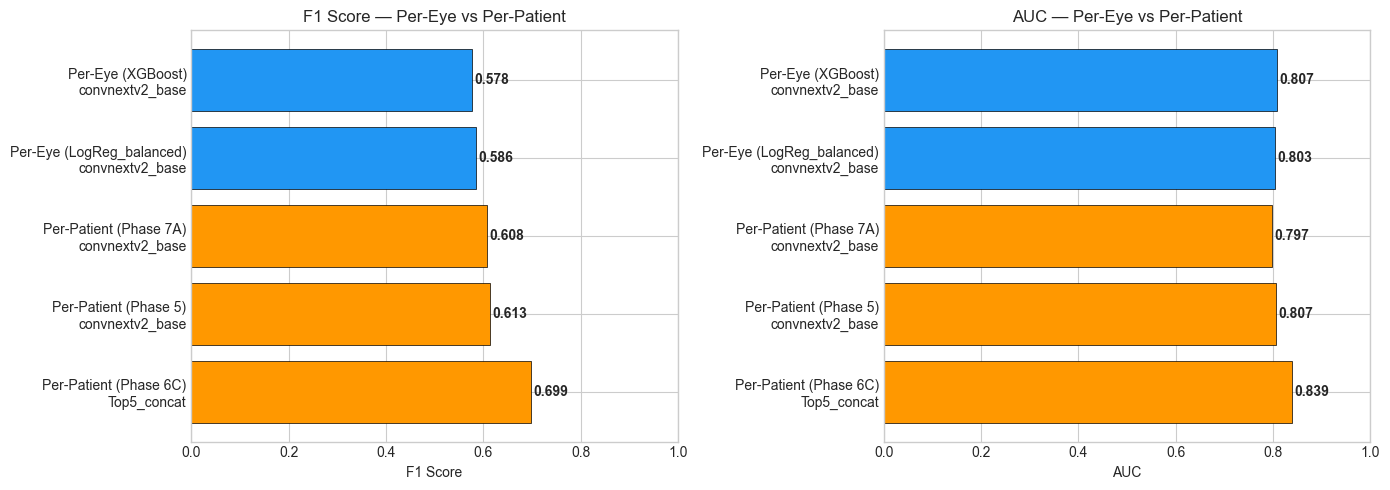


Chart saved to c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_per_eye_eval_any_dr\per_eye_vs_patient_comparison.png


In [8]:
# ——— Per-patient baselines (from main notebook, Phase 5 + 7A) ———
patient_baselines = [
    {"approach": "Per-Patient (Phase 5)", "embedding": "convnextv2_base",
     "classifier": "XGBoost", "f1": 0.613, "auc": 0.807},
    {"approach": "Per-Patient (Phase 7A)", "embedding": "convnextv2_base",
     "classifier": "LogReg_balanced", "f1": 0.608, "auc": 0.797},
    {"approach": "Per-Patient (Phase 6C)", "embedding": "Top5_concat",
     "classifier": "XGBoost", "f1": 0.699, "auc": 0.839},
]

# Per-eye best per classifier
per_eye_rows = []
for clf_name in ["LogReg_balanced", "XGBoost"]:
    sub = results_df[results_df["classifier"] == clf_name]
    if len(sub) > 0:
        best_row = sub.iloc[0]  # already sorted by F1
        per_eye_rows.append({
            "approach": f"Per-Eye ({clf_name})",
            "embedding": best_row["embedding"],
            "classifier": clf_name,
            "f1": best_row["f1"],
            "auc": best_row["auc"],
        })

comparison_df = pd.DataFrame(patient_baselines + per_eye_rows)
comparison_df = comparison_df.sort_values("f1", ascending=False).reset_index(drop=True)

print("=" * 80)
print("COMPARISON: Per-Eye vs Per-Patient")
print("=" * 80)
print(comparison_df.to_string(index=False, float_format="{:.3f}".format))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2196F3" if "Per-Eye" in a else "#FF9800" for a in comparison_df["approach"]]

for ax, metric, title in zip(axes, ["f1", "auc"], ["F1 Score", "AUC"]):
    bars = ax.barh(
        comparison_df["approach"] + "\n" + comparison_df["embedding"],
        comparison_df[metric],
        color=colors, edgecolor="black", linewidth=0.5
    )
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
    ax.set_xlabel(title)
    ax.set_title(f"{title} — Per-Eye vs Per-Patient")
    ax.set_xlim(0, 1.0)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_eye_vs_patient_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved to {RESULTS_DIR / 'per_eye_vs_patient_comparison.png'}")

## 7. Per-Embedding Comparison Chart

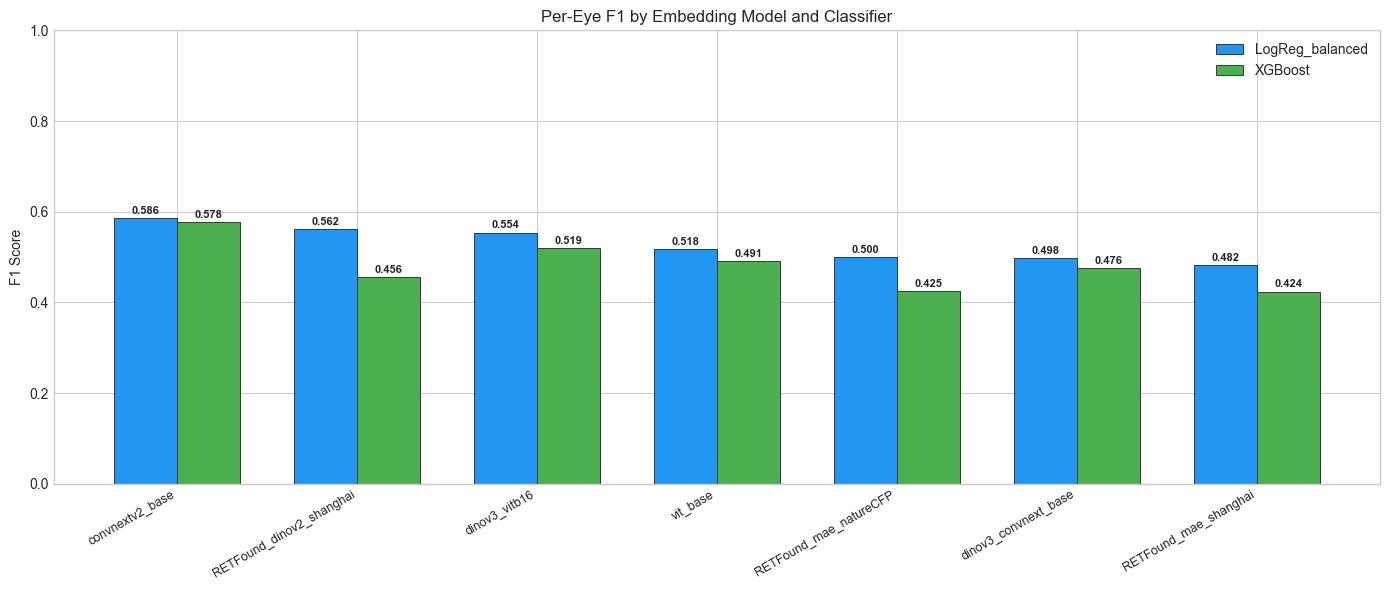

Chart saved to c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_per_eye_eval_any_dr\per_eye_f1_by_embedding.png


In [9]:
# Grouped bar chart: F1 per embedding, grouped by classifier
fig, ax = plt.subplots(figsize=(14, 6))

embeddings = results_df["embedding"].unique()
classifiers = results_df["classifier"].unique()
x = np.arange(len(embeddings))
width = 0.35
colors_clf = ["#2196F3", "#4CAF50"]

for i, clf_name in enumerate(classifiers):
    sub = results_df[results_df["classifier"] == clf_name]
    # Reorder to match embeddings order
    f1_vals = []
    for emb in embeddings:
        row = sub[sub["embedding"] == emb]
        f1_vals.append(float(row["f1"].iloc[0]) if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, f1_vals, width, label=clf_name,
                  color=colors_clf[i % len(colors_clf)], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_ylabel("F1 Score")
ax.set_title("Per-Eye F1 by Embedding Model and Classifier")
ax.set_xticks(x + width / 2)
ax.set_xticklabels(embeddings, rotation=30, ha="right", fontsize=9)
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_eye_f1_by_embedding.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to {RESULTS_DIR / 'per_eye_f1_by_embedding.png'}")

## 8. Per-Eye MLP with Bayesian Hyperparameter Search

Train an MLP (5 layers × 512 neurons) with Bayesian optimization of alpha and learning rate.
- **Architecture**: (512, 512, 512, 512, 512) — fixed
- **Batch size**: 64
- **Patience**: 15 (early stopping)
- **Bayesian search**: 30 iterations, 3-fold CV, optimizing alpha (1e-5 to 1e-1) and learning rate (1e-4 to 5e-4)

In [10]:
# ═══════════════════════════════════════════════════════════════
# MLP (5×512) + Bayesian Hyperparameter Search — Per-Eye
# ═══════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from skopt import BayesSearchCV
from skopt.space import Real, Categorical

# ——— Configuration ———
MLP_ARCHITECTURE = (512, 512, 512, 512, 512)  # Fixed: 5 layers × 512 neurons
MLP_BATCH_SIZE = 64
MLP_PATIENCE = 15
MLP_MAX_ITER = 400
N_BAYES_ITER = 30
BAYES_CV_FOLDS = 3

# Search space: only alpha and learning rate (architecture is fixed)
SEARCH_SPACE_MLP = {
    'alpha': Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    'learning_rate_init': Real(1e-4, 5e-4, prior='log-uniform', name='learning_rate_init'),
}

print(f"MLP Architecture: {MLP_ARCHITECTURE}")
print(f"Batch size: {MLP_BATCH_SIZE}")
print(f"Patience (early stopping): {MLP_PATIENCE}")
print(f"Max iterations: {MLP_MAX_ITER}")
print(f"Bayesian search: {N_BAYES_ITER} iterations, {BAYES_CV_FOLDS}-fold CV")
print(f"Search space: alpha ∈ [1e-5, 1e-1], lr ∈ [1e-4, 5e-4]")

# ——— Run MLP evaluation for all embeddings ———
mlp_results = []

for emb_idx, emb_path in enumerate(embedding_files):
    emb_stem = emb_path.stem
    display_name = emb_stem.replace("Embeddings_", "").replace("mbrset_", "").replace("_mbrset", "")
    print(f"\n{'='*70}")
    print(f"Embedding {emb_idx+1}/{len(embedding_files)}: {display_name}")
    print(f"{'='*70}")

    # ——— Load dataset (image-level) ———
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=labels_path,
        view=VIEW,
    )
    df = ds.df.copy()
    df["patient_id"] = df["patient_id"].astype(str)
    feat_cols = ds.feature_cols

    # Drop NaN labels
    df = df.dropna(subset=["task_any_dr"]).reset_index(drop=True)
    df["task_any_dr"] = df["task_any_dr"].astype(int)

    # ——— Split by patient ———
    train_mask = df["patient_id"].isin(train_patient_ids)
    test_mask  = df["patient_id"].isin(test_patient_ids)
    df_train = df[train_mask].reset_index(drop=True)
    df_test  = df[test_mask].reset_index(drop=True)

    X_train = df_train[feat_cols].values.astype(np.float32)
    y_train = df_train["task_any_dr"].values
    X_test  = df_test[feat_cols].values.astype(np.float32)
    y_test  = df_test["task_any_dr"].values

    # Handle NaNs
    X_train = np.nan_to_num(X_train, nan=0.0)
    X_test  = np.nan_to_num(X_test, nan=0.0)

    pos_train = y_train.sum()
    pos_test  = y_test.sum()
    print(f"  Images — train: {len(y_train)} (pos={pos_train}, {pos_train/len(y_train):.1%})")
    print(f"           test:  {len(y_test)}  (pos={pos_test}, {pos_test/len(y_test):.1%})")

    # ——— PCA ———
    n_components = min(PCA_N_COMPONENTS, X_train.shape[1], X_train.shape[0])
    pca = PCA(n_components=n_components, random_state=RANDOM_SEED)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca  = pca.transform(X_test)
    print(f"  PCA: {X_train.shape[1]}→{n_components} ({pca.explained_variance_ratio_.sum():.1%} variance)")

    # ——— Scale ———
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_pca)
    X_test_s  = scaler.transform(X_test_pca)

    # ——— Bayesian hyperparameter search ———
    print(f"\n  Running BayesSearchCV (MLP 5×512, {N_BAYES_ITER} iter, {BAYES_CV_FOLDS}-fold CV)...")

    base_mlp = MLPClassifier(
        hidden_layer_sizes=MLP_ARCHITECTURE,
        batch_size=MLP_BATCH_SIZE,
        max_iter=MLP_MAX_ITER,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=MLP_PATIENCE,
        random_state=RANDOM_SEED,
    )

    bayes_search = BayesSearchCV(
        estimator=base_mlp,
        search_spaces=SEARCH_SPACE_MLP,
        n_iter=N_BAYES_ITER,
        cv=BAYES_CV_FOLDS,
        n_jobs=1,
        scoring='f1',
        random_state=RANDOM_SEED,
        verbose=0,
    )

    bayes_search.fit(X_train_s, y_train)

    best_model = bayes_search.best_estimator_
    best_params = bayes_search.best_params_
    best_cv_f1 = bayes_search.best_score_

    print(f"  Best CV F1: {best_cv_f1:.4f}")
    print(f"  Best params: alpha={best_params['alpha']:.6f}, lr={best_params['learning_rate_init']:.6f}")

    # ——— Threshold optimization on train predictions ———
    train_proba = best_model.predict_proba(X_train_s)[:, 1]
    opt_threshold = find_optimal_threshold(
        y_train, train_proba, method=THRESHOLD_METHOD, grid_size=THRESHOLD_GRID_SIZE
    )

    # ——— Test evaluation ———
    test_proba = best_model.predict_proba(X_test_s)[:, 1]
    test_pred = (test_proba >= opt_threshold).astype(int)
    metrics = evaluate_binary(y_test, test_pred, test_proba)

    print(f"\n  MLP (5×512, BayesOpt):")
    print(f"    Threshold: {opt_threshold:.3f}")
    print(f"    F1={metrics['f1']:.3f}  Prec={metrics['precision']:.3f}  "
          f"Rec={metrics['recall']:.3f}  AUC={metrics['auc']:.3f}  BalAcc={metrics['bal_acc']:.3f}")
    cm = confusion_matrix(y_test, test_pred)
    print(f"    Confusion matrix: TN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

    mlp_results.append({
        "embedding": display_name,
        "classifier": "MLP_5x512_BayesOpt",
        "f1": metrics["f1"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "auc": metrics["auc"],
        "bal_acc": metrics["bal_acc"],
        "threshold": opt_threshold,
        "best_cv_f1": best_cv_f1,
        "best_alpha": best_params["alpha"],
        "best_lr": best_params["learning_rate_init"],
        "n_train": len(y_train),
        "n_test": len(y_test),
    })

print(f"\n{'='*70}")
print(f"Done! {len(mlp_results)} MLP results collected.")

MLP Architecture: (512, 512, 512, 512, 512)
Batch size: 64
Patience (early stopping): 15
Max iterations: 400
Bayesian search: 30 iterations, 3-fold CV
Search space: alpha ∈ [1e-5, 1e-1], lr ∈ [1e-4, 5e-4]

Embedding 1/7: convnextv2_base
  Images — train: 1949 (pos=469, 24.1%)
           test:  488  (pos=112, 23.0%)
  PCA: 1024→128 (94.7% variance)

  Running BayesSearchCV (MLP 5×512, 30 iter, 3-fold CV)...
  Best CV F1: 0.5280
  Best params: alpha=0.001518, lr=0.000410

  MLP (5×512, BayesOpt):
    Threshold: 0.373
    F1=0.530  Prec=0.671  Rec=0.438  AUC=0.761  BalAcc=0.687
    Confusion matrix: TN=352  FP=24  FN=63  TP=49

Embedding 2/7: dinov3_convnext_base
  Images — train: 1949 (pos=469, 24.1%)
           test:  488  (pos=112, 23.0%)
  PCA: 1024→128 (97.9% variance)

  Running BayesSearchCV (MLP 5×512, 30 iter, 3-fold CV)...
  Best CV F1: 0.4743
  Best params: alpha=0.002940, lr=0.000348

  MLP (5×512, BayesOpt):
    Threshold: 0.319
    F1=0.500  Prec=0.509  Rec=0.491  AUC=0.748 

c:\Users\Julian\OneDrive\Desktop\testing-retina-project\.venv\Lib\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [0.1, 0.0004999999999999999] before, using random point [0.01843073079820317, 0.00046074252871047177]
  warnings.warn(


  Best CV F1: 0.4706
  Best params: alpha=0.100000, lr=0.000304

  MLP (5×512, BayesOpt):
    Threshold: 0.284
    F1=0.509  Prec=0.500  Rec=0.518  AUC=0.706  BalAcc=0.682
    Confusion matrix: TN=318  FP=58  FN=54  TP=58

Done! 7 MLP results collected.


## 9. MLP Results Summary & Comparison

In [11]:
# ——— MLP results summary table ———
mlp_df = pd.DataFrame(mlp_results).sort_values("f1", ascending=False).reset_index(drop=True)

display_cols = ["embedding", "classifier", "f1", "precision", "recall", "auc",
                "bal_acc", "threshold", "best_cv_f1", "best_alpha", "best_lr"]
print("=" * 90)
print("MLP (5×512, BayesOpt) — Per-Eye Results")
print("=" * 90)
print(mlp_df[display_cols].to_string(index=False, float_format="%.3f"))

best_mlp = mlp_df.iloc[0]
print(f"\nBest MLP: {best_mlp['embedding']} → F1={best_mlp['f1']:.3f}, AUC={best_mlp['auc']:.3f}")

# Save MLP results
mlp_df.to_csv(RESULTS_DIR / "per_eye_mlp_results.csv", index=False)
print(f"Saved to {RESULTS_DIR / 'per_eye_mlp_results.csv'}")

# ——— Combined comparison: LogReg vs XGBoost vs MLP ———
print("\n" + "=" * 90)
print("Combined Comparison — Per-Eye: LogReg vs XGBoost vs MLP (5×512)")
print("=" * 90)

combined_df = pd.concat([results_df, mlp_df], ignore_index=True)
combined_df = combined_df.sort_values("f1", ascending=False).reset_index(drop=True)

show_cols = ["embedding", "classifier", "f1", "precision", "recall", "auc", "bal_acc", "threshold"]
print(combined_df[show_cols].to_string(index=False, float_format="%.3f"))

# Save combined
combined_df.to_csv(RESULTS_DIR / "per_eye_all_results.csv", index=False)
print(f"\nSaved combined results to {RESULTS_DIR / 'per_eye_all_results.csv'}")

MLP (5×512, BayesOpt) — Per-Eye Results
               embedding         classifier    f1  precision  recall   auc  bal_acc  threshold  best_cv_f1  best_alpha  best_lr
         convnextv2_base MLP_5x512_BayesOpt 0.530      0.671   0.438 0.761    0.687      0.373       0.528       0.002    0.000
           dinov3_vitb16 MLP_5x512_BayesOpt 0.518      0.617   0.446 0.760    0.682      0.255       0.516       0.016    0.000
                vit_base MLP_5x512_BayesOpt 0.509      0.500   0.518 0.706    0.682      0.284       0.471       0.100    0.000
    dinov3_convnext_base MLP_5x512_BayesOpt 0.500      0.509   0.491 0.748    0.675      0.319       0.474       0.003    0.000
RETFound_dinov2_shanghai MLP_5x512_BayesOpt 0.488      0.769   0.357 0.744    0.663      0.907       0.544       0.000    0.000
  RETFound_mae_natureCFP MLP_5x512_BayesOpt 0.482      0.566   0.420 0.702    0.662      0.319       0.470       0.025    0.000
   RETFound_mae_shanghai MLP_5x512_BayesOpt 0.429      0.500   0

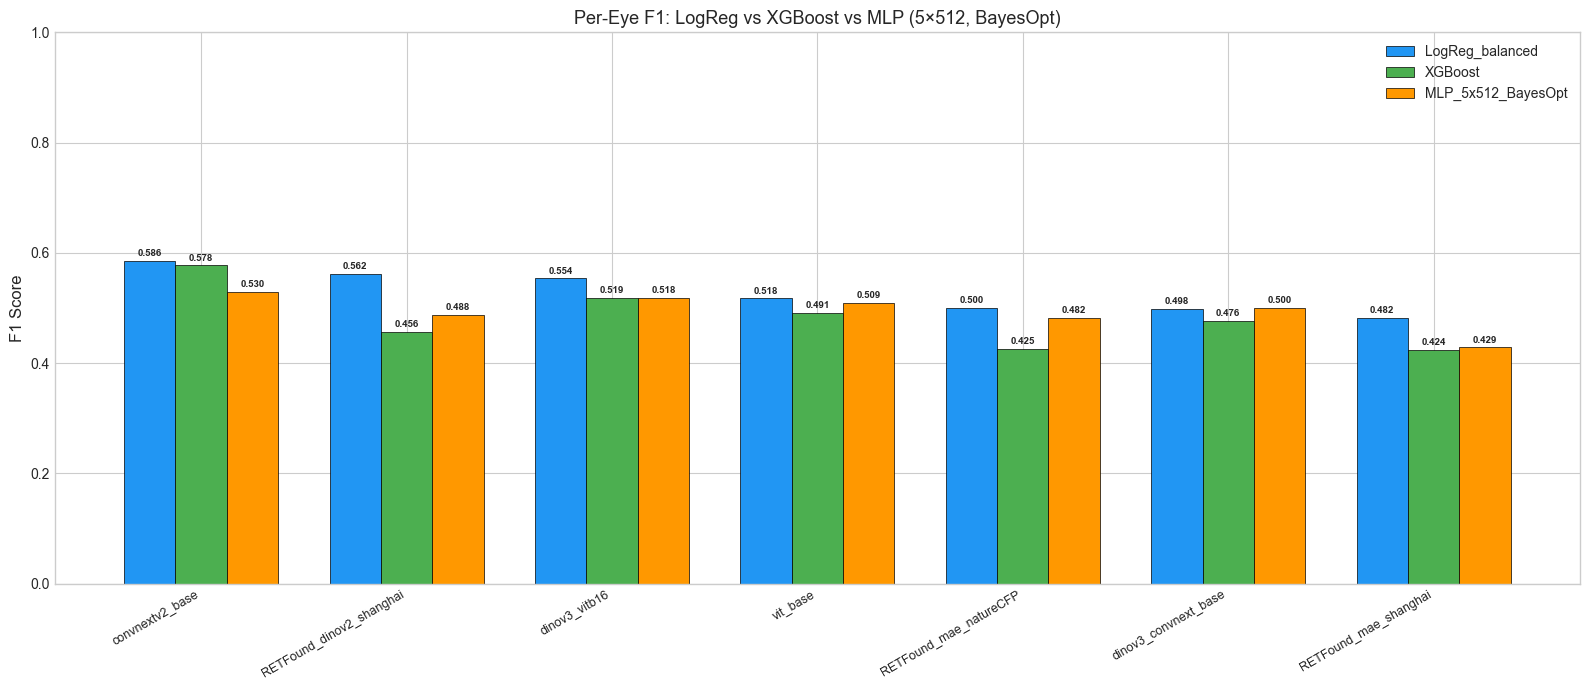

Chart saved to c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\mbrset_per_eye_eval_any_dr\per_eye_f1_logreg_xgb_mlp.png


In [12]:
# ——— Comparison chart: LogReg vs XGBoost vs MLP per embedding ———
fig, ax = plt.subplots(figsize=(16, 7))

embeddings_order = results_df.sort_values("f1", ascending=False)["embedding"].unique()
clf_names = ["LogReg_balanced", "XGBoost", "MLP_5x512_BayesOpt"]
colors_3 = ["#2196F3", "#4CAF50", "#FF9800"]
n_clf = len(clf_names)
x = np.arange(len(embeddings_order))
width = 0.25

for i, clf_name in enumerate(clf_names):
    sub = combined_df[combined_df["classifier"] == clf_name]
    f1_vals = []
    for emb in embeddings_order:
        row = sub[sub["embedding"] == emb]
        f1_vals.append(float(row["f1"].iloc[0]) if len(row) > 0 else 0)
    bars = ax.bar(x + i * width, f1_vals, width, label=clf_name,
                  color=colors_3[i], edgecolor="black", linewidth=0.5)
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Eye F1: LogReg vs XGBoost vs MLP (5×512, BayesOpt)", fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(embeddings_order, rotation=30, ha="right", fontsize=9)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_eye_f1_logreg_xgb_mlp.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved to {RESULTS_DIR / 'per_eye_f1_logreg_xgb_mlp.png'}")